Loading sessions...
  Session 2: ON=31, OFF=14, skipped=5
  Session 3: ON=9, OFF=31, skipped=0

Plot 1: Combined S2 + S3
  Saved: Plot1_Combined_Fixation_StimON_vs_OFF.png


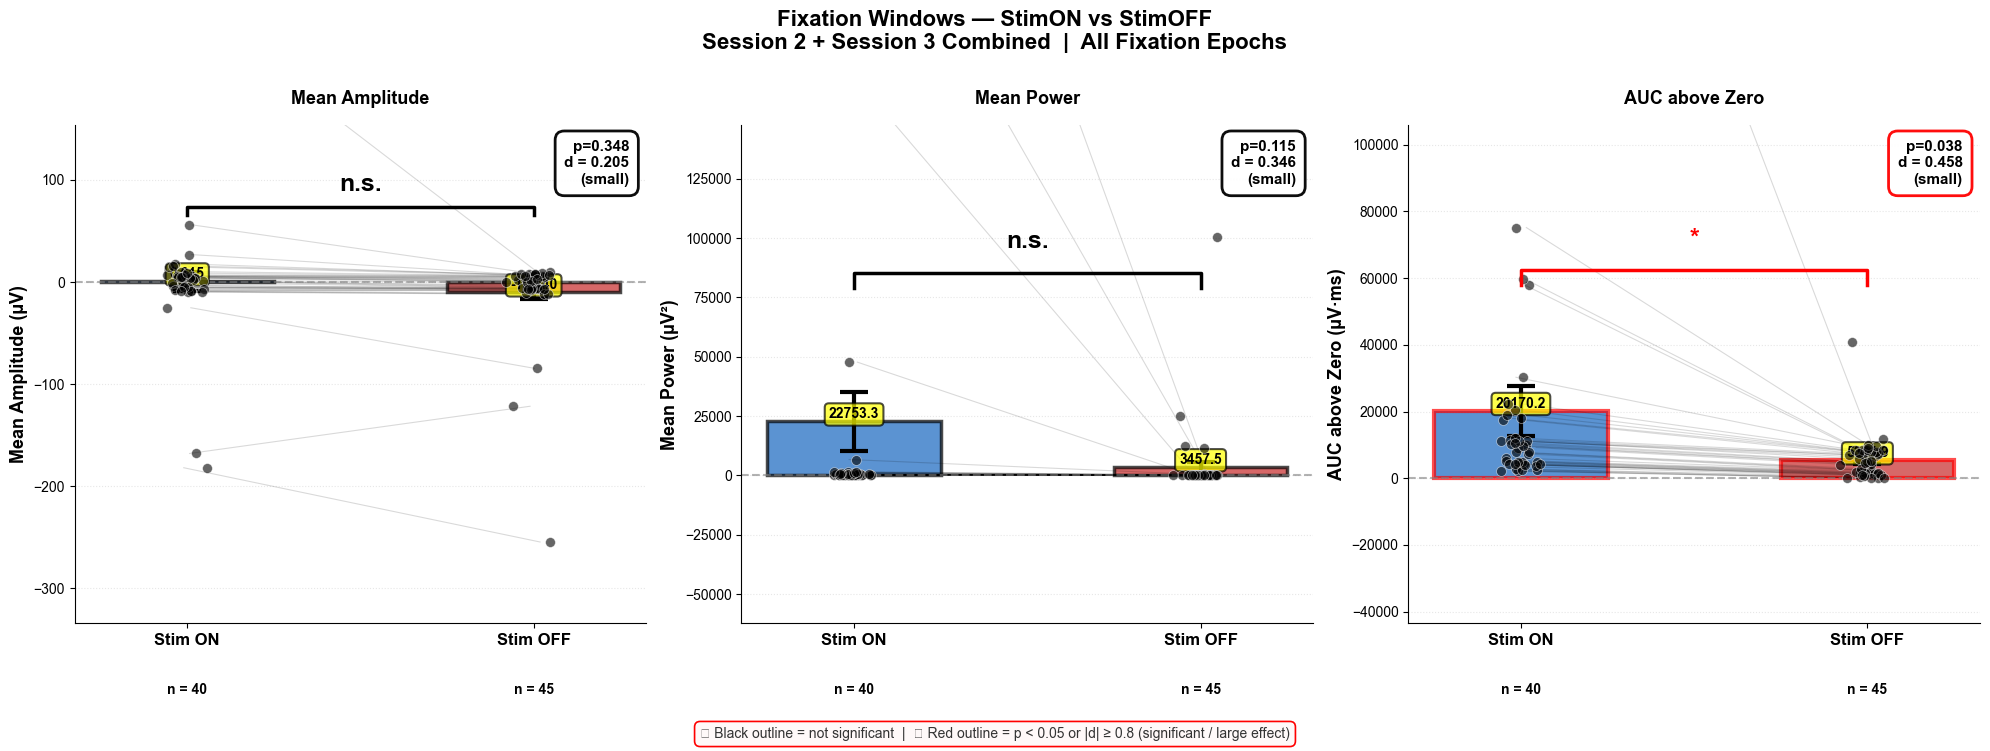

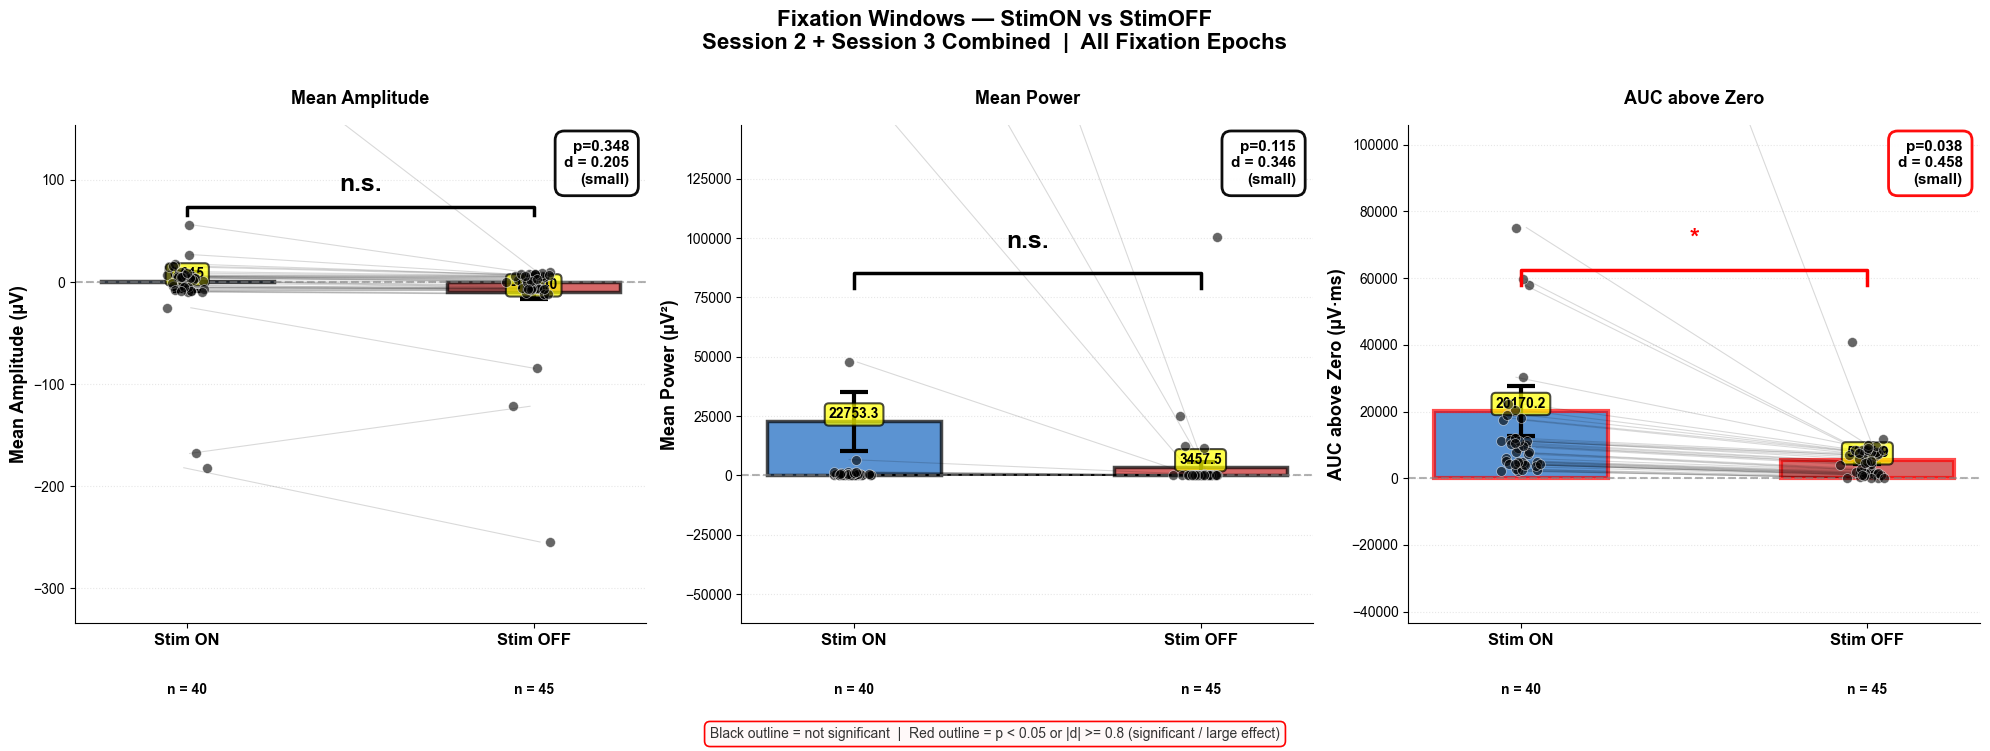


Plot 2: Session 2 only
  Saved: Plot2_Session2_Fixation_StimON_vs_OFF.png


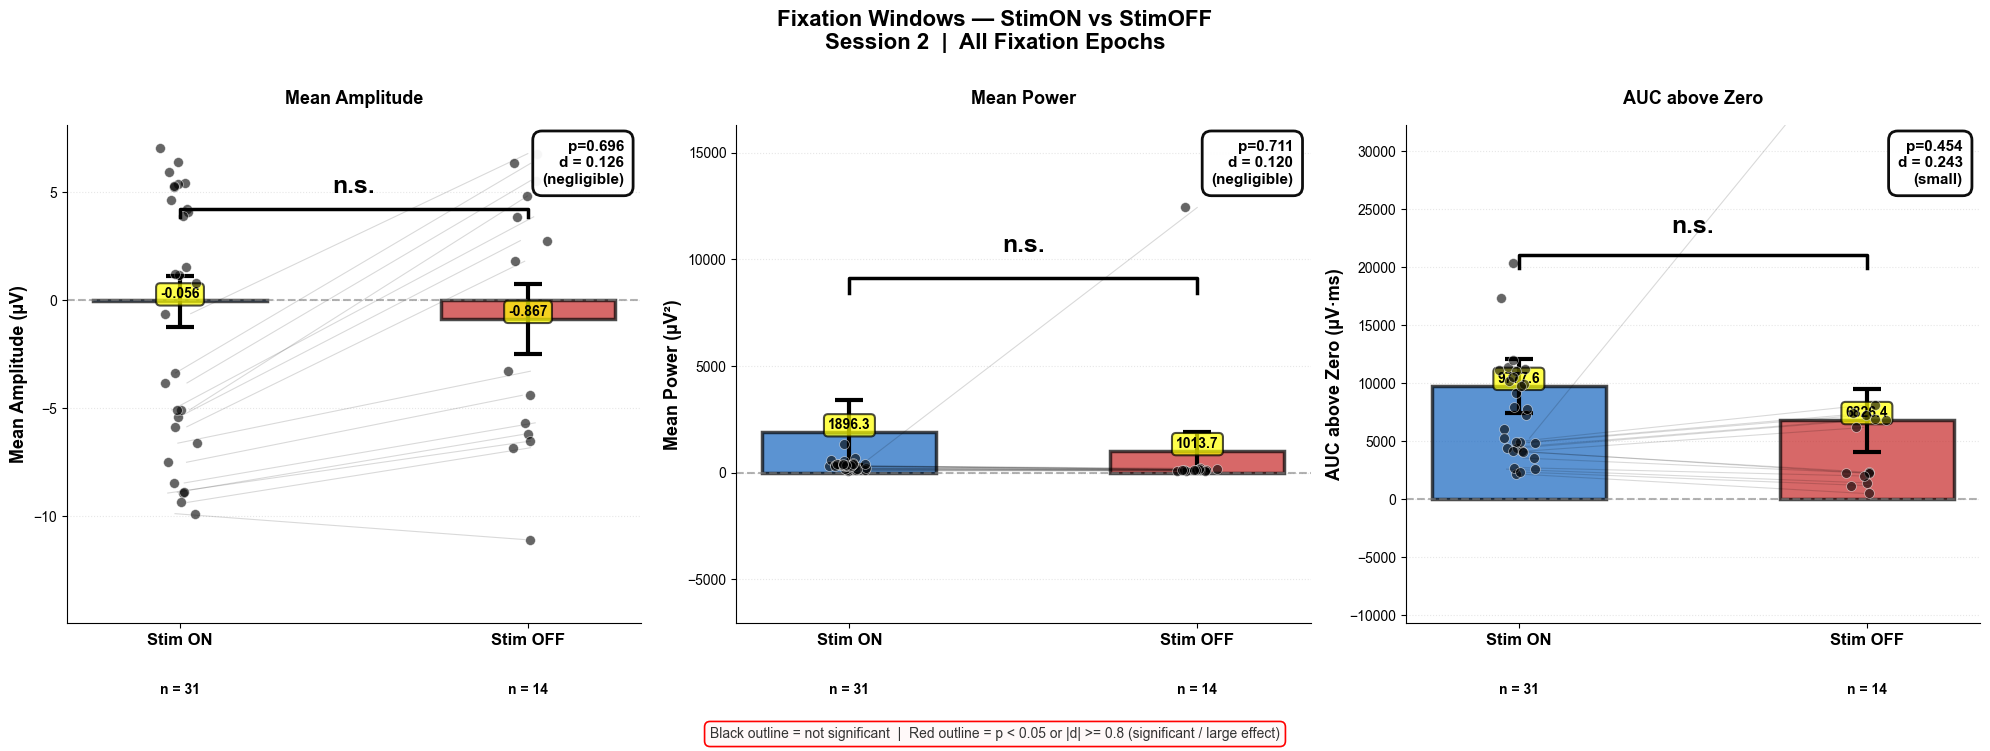


Plot 3: Session 3 only
  Saved: Plot3_Session3_Fixation_StimON_vs_OFF.png


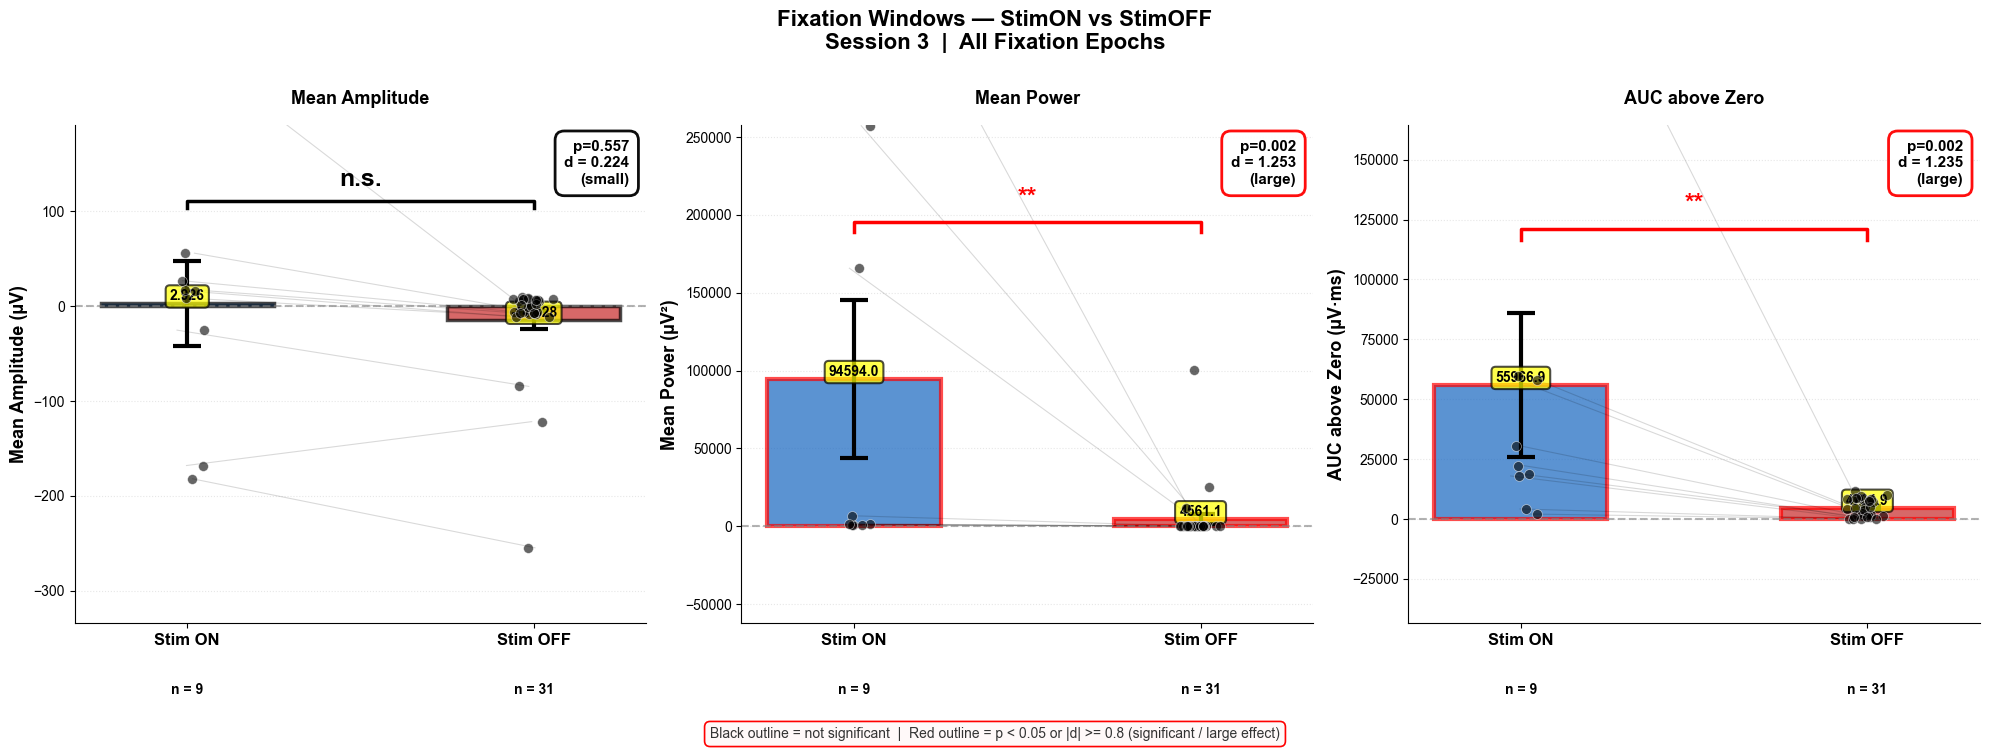


✓ All plots saved to: C:\Users\ASSUS\ATN\Digit Span Backwards\Fixation_Analysis


In [4]:
%matplotlib inline

"""
fixation_stim_analysis.py
=========================
Fixation window analysis: StimON vs StimOFF
Following reference plot style (2x3 grid, yellow mean labels, scatter, brackets)

Plots generated:
  1. Combined S2+S3 — all fixation windows: StimON vs OFF (3 metrics)
  2. Session 2 only — all fixation windows: StimON vs OFF (3 metrics)
  3. Session 3 only — all fixation windows: StimON vs OFF (3 metrics)

Significance colour: bright red bar edges when p<0.05 OR |d|>=0.8
"""

import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10

# ── PATHS — EDIT THESE ───────────────────────────────────────────────────────
SESSIONS = {
    2: dict(
        json   = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json",
        csv    = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv",
        events = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv",
        label  = "Session 2",
    ),
    3: dict(
        json   = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json",
        csv    = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv",
        events = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv",
        label  = "Session 3",
    ),
}
OUT_DIR = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Fixation_Analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

STIM_THRESH = 2.0
FS          = 250.0   # Hz → 4ms/sample

# ── COLOURS ──────────────────────────────────────────────────────────────────
COL_ON  = '#1565C0'   # blue  — stim ON
COL_OFF = '#C62828'   # red   — stim OFF

# ═════════════════════════════════════════════════════════════════════════════
# DATA LOADING & EPOCH EXTRACTION
# ═════════════════════════════════════════════════════════════════════════════
def parse_ints(s):
    return [int(x) for x in str(s).split(',') if x.strip()]

def load_fixation_epochs(paths):
    """Return dict with 'on' and 'off' lists of raw epoch arrays (µV)."""
    try:
        with open(paths['json']) as f: report = json.load(f)
        df  = pd.read_csv(paths['csv'],    encoding='utf-8-sig', low_memory=False)
        ev  = pd.read_csv(paths['events'], encoding='utf-8-sig', low_memory=False)
    except Exception as e:
        print(f"  ✗ Could not load {paths['label']}: {e}")
        return None

    # Alignment anchor
    stk = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            c = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and c > 0.0:
                stk = pkt['TicksInMs']; break
            prev = c
        if stk: break
    if stk is None: return None

    MO = stk - int(df['Welcome.TargetOnsetTime'].iloc[0])
    def to_rel(ms): return float(ms) + MO - stk

    # Build LEFT channel LFP signal
    all_t, all_s = [], []
    for s in report['BrainSenseTimeDomain']:
        if s['Channel'] != 'ZERO_THREE_LEFT': continue
        tks = parse_ints(s['TicksInMses'])
        szs = parse_ints(s['GlobalPacketSizes'])
        dat = s['TimeDomainData']; idx = 0
        for tick, sz in zip(tks, szs):
            t_arr = (tick - stk) + np.arange(sz) * (1000.0 / FS)
            all_t.extend(t_arr); all_s.extend(dat[idx:idx+sz]); idx += sz
    t_sig = np.array(all_t); sig = np.array(all_s)
    o = np.argsort(t_sig); t_sig = t_sig[o]; sig = sig[o]

    # LFP stimulation arrays (step-hold)
    tl, ml = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            tl.append(pkt['TicksInMs']); ml.append(pkt['Left']['mA'])
    rl = np.array(tl, dtype=float) - stk
    ma = np.array(ml, dtype=float)

    def win_on(t0, t1):
        """Step-hold stim detection: uses last packet before window + any inside."""
        i = int(np.searchsorted(rl, t0, side='right')) - 1
        vals = list(ma[(rl > t0) & (rl <= t1)])
        if i >= 0: vals.insert(0, ma[i])
        return bool(vals and np.any(np.array(vals) >= STIM_THRESH))

    def epoch(t0, t1):
        return sig[(t_sig >= t0) & (t_sig < t1)]

    def eta(etype, tn):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == tn)]
        return [to_rel(float(x)) for x in rows['Time_ms']]

    # Collect ALL fixation windows across all trials
    # Fixation window = Fixation Start → Stimulus Start (full ~1013ms period)
    epochs_on, epochs_off = [], []
    skipped = 0

    for tn in sorted(ev['Trial_Number'].dropna().unique().astype(int)):
        row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if row.empty: continue
        nd = int(row.iloc[0]['Num_Digits'])

        fix_starts  = eta('Fixation Start',  tn)
        stim_starts = eta('Stimulus Start',  tn)

        for i in range(nd):
            if i >= len(fix_starts) or i >= len(stim_starts):
                skipped += 1; continue
            t0, t1 = fix_starts[i], stim_starts[i]
            ep = epoch(t0, t1)
            if len(ep) == 0 or not np.isfinite(ep).all():
                skipped += 1; continue
            if win_on(t0, t1):
                epochs_on.append(ep)
            else:
                epochs_off.append(ep)

    print(f"  {paths['label']}: ON={len(epochs_on)}, OFF={len(epochs_off)}, skipped={skipped}")
    return {'on': epochs_on, 'off': epochs_off, 'label': paths['label']}

# ═════════════════════════════════════════════════════════════════════════════
# METRIC CALCULATION  (matching reference code logic exactly)
# ═════════════════════════════════════════════════════════════════════════════
def calc_amplitude(ep):
    """Mean Amplitude (µV) — direct mean of raw signal, matching reference."""
    return float(np.mean(ep))

def calc_power(ep):
    """Mean Power (µV²) — mean of squared signal, matching reference."""
    return float(np.mean(ep ** 2))

def calc_auc(ep):
    """AUC above zero (µV·ms) — trapezoid of max(signal,0), matching reference."""
    dt = 1000.0 / FS   # ms per sample
    time_ms = np.arange(len(ep)) * dt
    return float(np.trapezoid(np.maximum(ep, 0), time_ms))

METRIC_FUNCS  = [calc_amplitude, calc_power, calc_auc]
METRIC_LABELS = ['Mean Amplitude (µV)', 'Mean Power (µV²)', 'AUC above Zero (µV·ms)']
METRIC_FMT    = ['{:.3f}', '{:.1f}', '{:.1f}']

def extract_metric_vals(epochs, metric_fn):
    vals = [metric_fn(ep) for ep in epochs]
    return np.array([v for v in vals if np.isfinite(v)])

# ═════════════════════════════════════════════════════════════════════════════
# STATS  (matching reference functions)
# ═════════════════════════════════════════════════════════════════════════════
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    if n1 < 2 or n2 < 2: return np.nan
    v1, v2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    sp = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
    return (np.mean(g1) - np.mean(g2)) / sp if sp > 0 else np.nan

def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

def fmt_p(p):
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

def get_effect(d):
    a = abs(d)
    if a < 0.2: return 'negligible'
    if a < 0.5: return 'small'
    if a < 0.8: return 'medium'
    return 'large'

def is_highlight(p, d):
    """Bright red if significant OR large effect."""
    return (not np.isnan(p) and p < 0.05) or (not np.isnan(d) and abs(d) >= 0.8)

# ═════════════════════════════════════════════════════════════════════════════
# SINGLE SUBPLOT  (reference style: bars + scatter + bracket + stats box)
# ═════════════════════════════════════════════════════════════════════════════
def draw_panel(ax, data1, data2, label1, label2, col1, col2, ylabel, title):
    """Draw one comparison panel in the exact reference style."""

    # ── no data guard ────────────────────────────────────────────────────────
    if len(data1) == 0 and len(data2) == 0:
        ax.text(0.5, 0.5, 'Data not available',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#888888')
        ax.set_title(title, fontweight='bold', fontsize=13, pad=15)
        ax.axis('off'); return

    n1, n2 = len(data1), len(data2)
    m1 = float(np.mean(data1)) if n1 > 0 else 0.0
    m2 = float(np.mean(data2)) if n2 > 0 else 0.0
    s1 = float(stats.sem(data1)) if n1 > 1 else 0.0
    s2 = float(stats.sem(data2)) if n2 > 1 else 0.0

    t_stat, p_val = (stats.ttest_ind(data1, data2)
                     if n1 > 1 and n2 > 1
                     else (np.nan, np.nan))
    d = cohens_d(data1, data2)

    # ── colour: bright red if significant or large effect ────────────────────
    highlight = is_highlight(p_val, d)
    bar_edge  = '#FF0000' if highlight else 'black'
    lw_edge   = 3.0       if highlight else 2.5

    # ── bars ─────────────────────────────────────────────────────────────────
    bars = ax.bar(
        [0, 1], [m1, m2], yerr=[s1, s2], capsize=10, width=0.5,
        color=[col1, col2], alpha=0.7,
        edgecolor=bar_edge, linewidth=lw_edge,
        error_kw={'linewidth': 3, 'ecolor': 'black', 'capthick': 3}
    )

    # ── mean value labels (yellow boxes, reference style) ────────────────────
    fmt = ylabel.split('(')[1].split(')')[0] if '(' in ylabel else 'µV'
    if 'µV²' in ylabel:     val_fmt = '{:.1f}'
    elif '·ms' in ylabel:   val_fmt = '{:.1f}'
    else:                    val_fmt = '{:.3f}'

    for bar, mean_v in zip(bars, [m1, m2]):
        ax.text(bar.get_x() + bar.get_width() / 2., mean_v,
                val_fmt.format(mean_v),
                ha='center', va='bottom', fontweight='bold', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow',
                          alpha=0.7, edgecolor='black', linewidth=1.5))

    # ── individual data points ────────────────────────────────────────────────
    np.random.seed(42)
    ax.scatter(np.random.normal(0, 0.03, n1), data1,
               color='black', alpha=0.6, s=50, zorder=3,
               edgecolors='white', linewidths=0.5)
    ax.scatter(np.random.normal(1, 0.03, n2), data2,
               color='black', alpha=0.6, s=50, zorder=3,
               edgecolors='white', linewidths=0.5)

    # ── connecting lines between matched pairs (reference style) ─────────────
    n_pairs = min(n1, n2)
    d1_sorted = np.sort(data1)[:n_pairs]
    d2_sorted = np.sort(data2)[:n_pairs]
    for i in range(n_pairs):
        ax.plot([np.random.normal(0, 0.02), 1 + np.random.normal(0, 0.02)],
                [d1_sorted[i], d2_sorted[i]],
                'k-', alpha=0.15, linewidth=0.8, zorder=1)

    # ── axis styling ─────────────────────────────────────────────────────────
    ax.set_xticks([0, 1])
    ax.set_xticklabels([label1, label2], fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=13)
    ax.set_title(title, fontweight='bold', fontsize=13, pad=15)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.grid(True, alpha=0.3, linestyle=':', axis='y')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── significance bracket ──────────────────────────────────────────────────
    all_v = np.concatenate([data1, data2])
    y_range = max(max(m1+s1, m2+s2) - min(m1-s1, m2-s2),
                  all_v.max() - all_v.min())
    if y_range < 0.1: y_range = 1.0
    bracket_h = max(m1+s1, m2+s2) + y_range * 0.12

    brk_col = '#FF0000' if highlight else 'black'
    ax.plot([0, 0, 1, 1],
            [bracket_h - y_range*0.015, bracket_h,
             bracket_h, bracket_h - y_range*0.015],
            color=brk_col, linewidth=2.5, zorder=10)
    ax.text(0.5, bracket_h + y_range*0.02,
            get_sig(p_val) if not np.isnan(p_val) else 'n/a',
            ha='center', va='bottom', fontsize=18, fontweight='bold',
            color=brk_col, zorder=10)

    # ── stats box ─────────────────────────────────────────────────────────────
    p_txt = fmt_p(p_val) if not np.isnan(p_val) else 'n/a'
    d_txt = f'd = {d:.3f}' if not np.isnan(d) else 'd = n/a'
    box_edge = '#FF0000' if highlight else 'black'
    ax.text(0.97, 0.97,
            f'{p_txt}\n{d_txt}\n({get_effect(d)})',
            transform=ax.transAxes, fontsize=11, va='top', ha='right',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
                      edgecolor=box_edge, alpha=0.95, linewidth=2))

    # ── n labels below x-axis ────────────────────────────────────────────────
    ax.text(0, -0.12, f'n = {n1}', transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=10, fontweight='bold')
    ax.text(1, -0.12, f'n = {n2}', transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=10, fontweight='bold')

    ax.set_ylim(all_v.min() - y_range*0.15, bracket_h + y_range*0.15)

# ═════════════════════════════════════════════════════════════════════════════
# BUILD ONE 2×3 FIGURE  (3 metrics × 2 rows → fits in 2 rows, 3 cols = 1 row)
# We use 1×3 layout (one row, 3 metric panels) per figure
# ═════════════════════════════════════════════════════════════════════════════
def make_figure(epochs_on, epochs_off, label_on, label_off, title, fname):
    """One figure, 1x3 panels - one per metric. Shows inline in notebook."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.patch.set_facecolor('white')
    fig.suptitle(title, fontweight='bold', fontsize=16, y=1.01)

    for ax, metric_fn, ylabel in zip(axes, METRIC_FUNCS, METRIC_LABELS):
        d1 = extract_metric_vals(epochs_on,  metric_fn)
        d2 = extract_metric_vals(epochs_off, metric_fn)
        draw_panel(ax, d1, d2, label_on, label_off,
                   COL_ON, COL_OFF, ylabel, ylabel.split(' (')[0])

    fig.text(0.5, -0.03,
             'Black outline = not significant  |  '
             'Red outline = p < 0.05 or |d| >= 0.8 (significant / large effect)',
             ha='center', fontsize=10, color='#333',
             bbox=dict(boxstyle='round,pad=0.4', fc='#FFF9F9', ec='#FF0000', lw=1.2))
    plt.tight_layout()
    # Save to OUT_DIR if accessible, silently skip if path does not exist
    try:
        fig.savefig(OUT_DIR / fname, dpi=180, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {fname}")
    except Exception:
        pass
    plt.show()
    plt.close(fig)

# ═════════════════════════════════════════════════════════════════════════════
# MAIN
# ═════════════════════════════════════════════════════════════════════════════
print("Loading sessions...")
sdata = {}
for sid, paths in SESSIONS.items():
    d = load_fixation_epochs(paths)
    if d: sdata[sid] = d

# ── PLOT 1: Combined S2 + S3 ─────────────────────────────────────────────────
print("\nPlot 1: Combined S2 + S3")
if sdata:
    all_on  = sum([sdata[k]['on']  for k in sdata], [])
    all_off = sum([sdata[k]['off'] for k in sdata], [])
    sess_labels = ' + '.join(sdata[k]['label'] for k in sorted(sdata))
    make_figure(
        all_on, all_off,
        'Stim ON', 'Stim OFF',
        f'Fixation Windows — StimON vs StimOFF\n{sess_labels} Combined  |  All Fixation Epochs',
        'Plot1_Combined_Fixation_StimON_vs_OFF.png'
    )
else:
    print("  No data available")

# ── PLOT 2: Session 2 only ───────────────────────────────────────────────────
print("\nPlot 2: Session 2 only")
if 2 in sdata:
    make_figure(
        sdata[2]['on'], sdata[2]['off'],
        'Stim ON', 'Stim OFF',
        f"Fixation Windows — StimON vs StimOFF\n{sdata[2]['label']}  |  All Fixation Epochs",
        'Plot2_Session2_Fixation_StimON_vs_OFF.png'
    )
else:
    print("  Session 2 not available")

# ── PLOT 3: Session 3 only ───────────────────────────────────────────────────
print("\nPlot 3: Session 3 only")
if 3 in sdata:
    make_figure(
        sdata[3]['on'], sdata[3]['off'],
        'Stim ON', 'Stim OFF',
        f"Fixation Windows — StimON vs StimOFF\n{sdata[3]['label']}  |  All Fixation Epochs",
        'Plot3_Session3_Fixation_StimON_vs_OFF.png'
    )
else:
    print("  Session 3 not available — plot will show 'Data not available'")
    # Still make the figure with empty data to show placeholder
    make_figure(
        [], [],
        'Stim ON', 'Stim OFF',
        "Fixation Windows — StimON vs StimOFF\nSession 3  |  All Fixation Epochs",
        'Plot3_Session3_Fixation_StimON_vs_OFF.png'
    )

print(f"\n✓ All plots saved to: {OUT_DIR}")